In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [2]:
df = pd.read_csv("house_price.csv")
print(df.head())

   size_sqft  bedrooms  bathrooms  age   price
0      837.7         3          4   14  418705
1      974.4         5          3   27  411230
2     1111.1         2          2   40  203755
3     1248.8         4          1   13  396460
4     1385.5         1          4   26  408985


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   size_sqft  200 non-null    float64
 1   bedrooms   200 non-null    int64  
 2   bathrooms  200 non-null    int64  
 3   age        200 non-null    int64  
 4   price      200 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 7.9 KB


In [21]:
df.isnull().sum()

size_sqft    0
bedrooms     0
bathrooms    0
age          0
price        0
dtype: int64

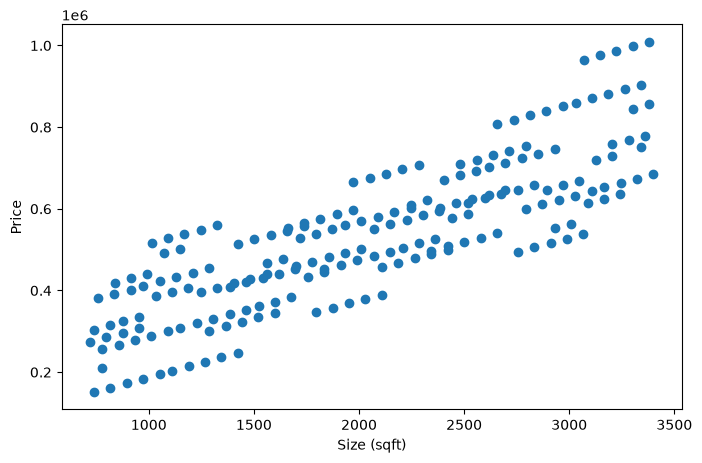

In [28]:
%matplotlib inline
plt.figure(figsize=(8,5))
plt.scatter(df['size_sqft'], df['price'])
plt.xlabel('Size (sqft)')
plt.ylabel('Price')
plt.show()



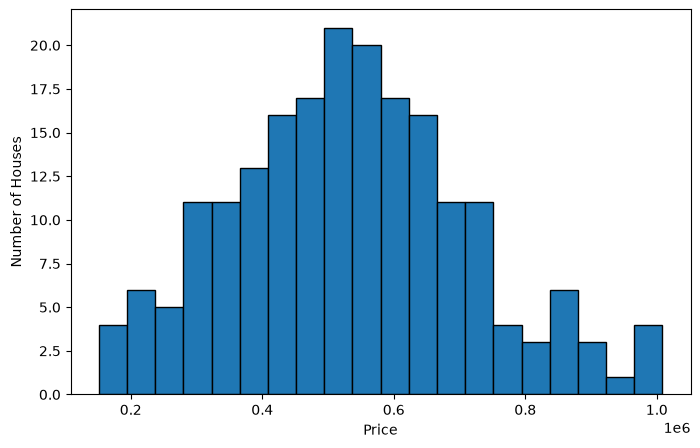

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df['price'],bins=20,edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.show()

In [4]:
feature=["size_sqft","bedrooms","bathrooms","age"]
x=df[feature]
y=df['price']
print("X shape:",x.shape)
print("Y shape:",y.shape)

X shape: (200, 4)
Y shape: (200,)


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print('Train Sample',len(x_train))
print('Test Sample',len(x_test))

Train Sample 160
Test Sample 40


In [10]:
model=LinearRegression()

In [25]:
model.fit(x_train, y_train)
print("Training finished!")
print("Intercept (b0):", round(model.intercept_, 2))
print("Coefficients:")
for name, coef in zip(feature, model.coef_):
    print(f"  {name}: {coef:.2f}")

Training finished!
Intercept (b0): 23762.57
Coefficients:
  size_sqft: 179.32
  bedrooms: 35897.60
  bathrooms: 54983.50
  age: -4999.17


In [26]:
#size_sqft,bedrooms,bathrooms,age,price
#837.7,3,4,14,418705

new_house = pd.DataFrame({
    "size_sqft": [837.7],
    "bedrooms": [3],
    "bathrooms": [4],
    "age": [1]
})

predicted_price = model.predict(new_house[feature])[0]

print(f"Predicted price: {predicted_price:,.0f}")

Predicted price: 496,610
